In [48]:
import pandas as pd
import glob

file = glob.glob("/content/Dataset.xlsx")[0]

df = pd.read_excel(file)

df.head()

,Year,January,February,March,April,May,June,July,August,September,October,November,December,Type
0,2021,4207,4000,4431,4395,4249,4157,4918,4569,4811,4177,3887,3710,Injuries
1,2022,3097,2771,3981,4717,5291,4987,4949,5144,5285,5686,5021,5062,Injuries
2,2023,5396,4690,5798,6163,6054,6001,6103,6089,6201,6723,6156,5642,Injuries
3,2024,5989,5241,6478,6724,6097,6063,6392,6856,6722,7155,6245,6400,Injuries
4,2025,6332,5811,7290,6674,6808,7318,6851,7598,8117,8245,7162,6347,Injuries


In [49]:
excel = pd.ExcelFile(file)

print(excel.sheet_names)

['Month', 'Gender', 'Age', 'Road User', 'Vehicle Type', 'Calender', 'Bridge', 'Summary', 'Gov_month', 'Gov_vehicle', 'Gov_Road User', 'Gov_Gender', 'Gov_Age']


In [50]:
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Number of rows and columns: (10, 14)

Column names:
['Year', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Type']

Missing values:
Year         0
January      0
February     0
March        0
April        0
May          0
June         0
July         0
August       0
September    0
October      0
November     0
December     0
Type         0
dtype: int64

Duplicate rows: 0


In [51]:
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [52]:
df.describe()


,year,january,february,march,april,may,june,july,august,september,october,november,december
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,2023.000000,2741.400000,2478.400000,3067.800000,3157.600000,3120.600000,3121.300000,3199.300000,3313.500000,3387.100000,3482.60000,3101.200000,2976.300000
std,1.490712,2546.994796,2273.646909,2819.873472,2814.954122,2796.233268,2838.716183,2847.882022,3001.560196,3116.655988,3240.85401,2860.993487,2693.137577
min,2021.000000,407.000000,394.000000,465.000000,502.000000,410.000000,469.000000,407.000000,444.000000,420.000000,439.00000,384.000000,431.000000
25%,2022.000000,486.000000,470.750000,569.500000,558.250000,525.750000,518.750000,557.750000,558.500000,544.750000,588.50000,529.000000,513.500000
50%,2023.000000,1834.000000,1637.000000,2288.500000,2558.000000,2464.500000,2397.500000,2828.000000,2666.000000,2743.500000,2446.00000,2250.000000,2186.000000
75%,2024.000000,5098.750000,4517.500000,5456.250000,5801.500000,5863.250000,5747.500000,5814.500000,5852.750000,5972.000000,6463.75000,5872.250000,5497.000000
max,2025.000000,6332.000000,5811.000000,7290.000000,6724.000000,6808.000000,7318.000000,6851.000000,7598.000000,8117.000000,8245.00000,7162.000000,6400.000000


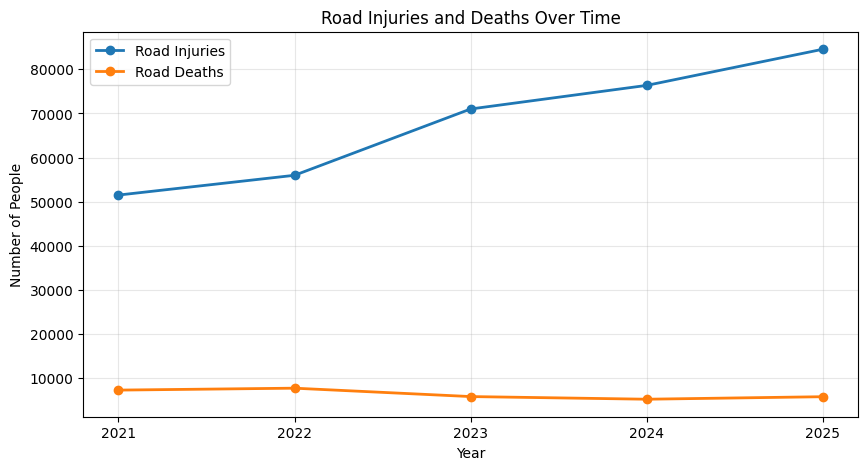

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    yearly["Year"],
    yearly["Road Injuries"],
    marker="o",
    linewidth=2,
    label="Road Injuries"
)

plt.plot(
    yearly["Year"],
    yearly["Road Deaths"],
    marker="o",
    linewidth=2,
    label="Road Deaths"
)

plt.title("Road Injuries and Deaths Over Time")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.xticks(yearly["Year"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

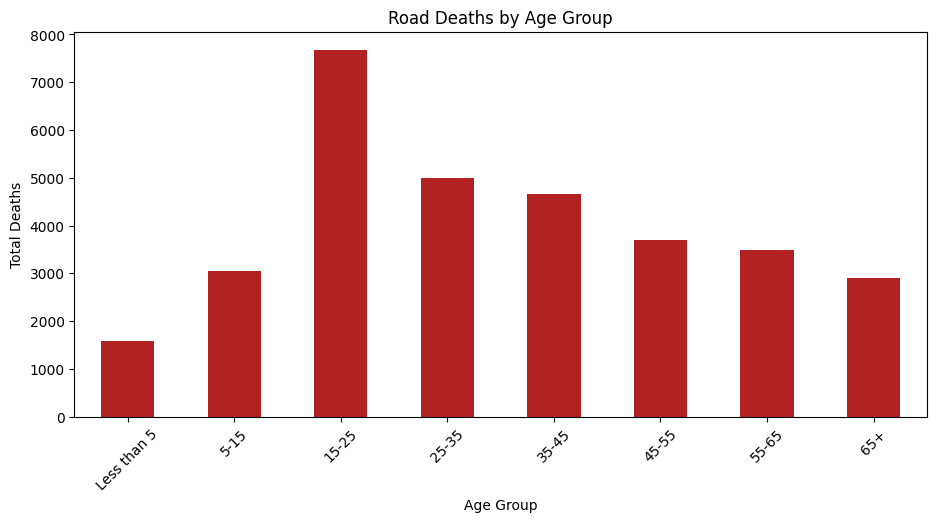

In [54]:
age_cols = [
    "Less than 5",
    "5-15",
    "15-25",
    "25-35",
    "35-45",
    "45-55",
    "55-65",
    "65+"
]

age_totals = deaths_age[age_cols].sum()

plt.figure(figsize=(11, 5))

age_totals.plot(
    kind="bar",
    color="firebrick"
)

plt.title("Road Deaths by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)

plt.show()

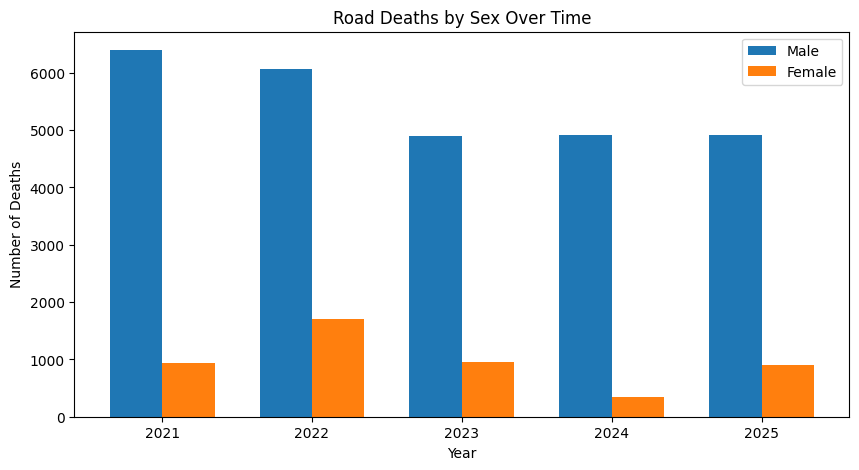

In [55]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(deaths_sex))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    deaths_sex["Male"],
    width,
    label="Male"
)

plt.bar(
    x + width/2,
    deaths_sex["Female"],
    width,
    label="Female"
)

plt.title("Road Deaths by Sex Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.xticks(x, deaths_sex["Year"])
plt.legend()

plt.show()

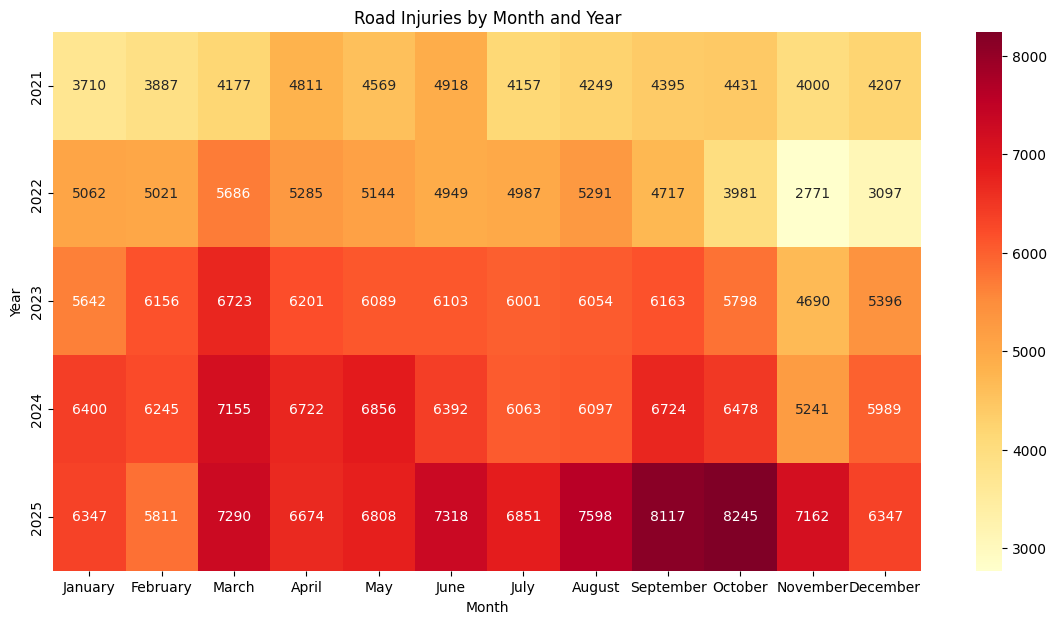

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

month_data = injuries_month.set_index("Year")[months]

plt.figure(figsize=(14, 7))

sns.heatmap(
    month_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Road Injuries by Month and Year")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

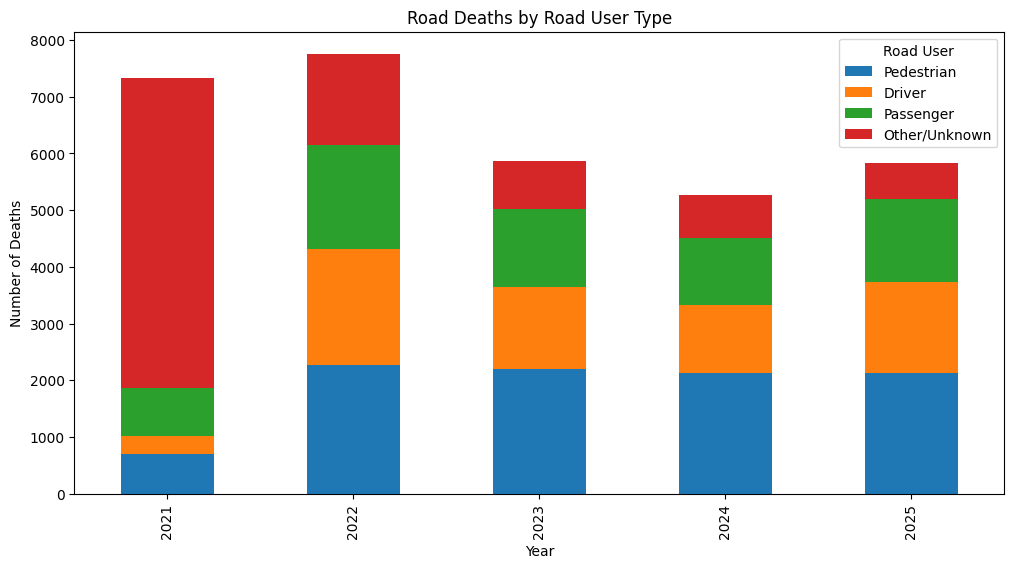

In [57]:
user_cols = [
    "Pedestrian",
    "Driver",
    "Passenger",
    "Other/Unknown"
]

deaths_user.set_index("Year")[user_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Road Deaths by Road User Type")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.legend(title="Road User")

plt.show()

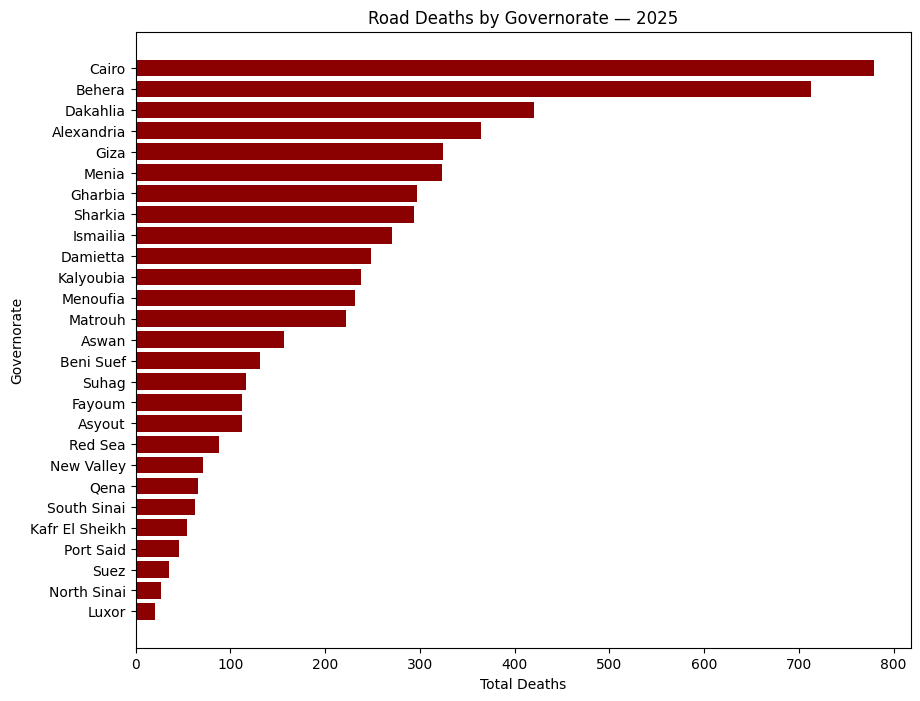

In [58]:
gov = deaths_gov.sort_values(
    "Total Deaths",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    gov["Governorate"],
    gov["Total Deaths"],
    color="darkred"
)

plt.title("Road Deaths by Governorate — 2025")
plt.xlabel("Total Deaths")
plt.ylabel("Governorate")

plt.show()